# Defining Natural Numbers - Images

## Setup

Set up `sys.path` to work while within a subfolder.

In [1]:
import sys
sys.path.append("../..")

Enable this if working within VSCode.

In [2]:
import os

if not os.environ.get("NOTEBOOK_PATH"):
    os.environ["NOTEBOOK_PATH"] = "notebooks/part-1/constructing-numbers.ipynb"

Manim-related imports.

In [3]:
from manim import *
from manim_utils import *

Set up the image generation cell magic.

In [4]:
%load_ext magics.generate_image

Loaded extension.


## Scenes

### Various Examples of 3

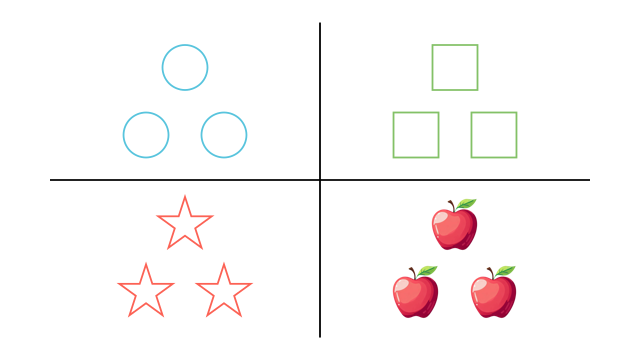

In [5]:
%%generate_image three ThreeDiagram

CIRCLE_WIDTH = 1
CIRCLE_COLOUR = BLUE

SQUARE_WIDTH = 1
SQUARE_COLOUR = GREEN

STAR_WIDTH = 1.25
STAR_COLOUR = RED


class ThreeDiagram(Scene):
    def construct(self):
        # Define quadrants
        horizontal_line = Line(LEFT*6, RIGHT*6, color=BLACK)
        vertical_line = Line(UP*3.5, DOWN*3.5, color=BLACK)
        self.add(horizontal_line, vertical_line)

        # Create the three circles
        circles = VGroup(
            *[Circle(radius=CIRCLE_WIDTH/2, color=CIRCLE_COLOUR) for i in range(3)]
        )
        arrange_circular(*circles)
        circles.shift(UP*1.5 + LEFT*3)
        self.add(circles)

        # Create the three squares
        squares = VGroup(
            *[Square(side_length=SQUARE_WIDTH, color=SQUARE_COLOUR) for i in range(3)]
        )
        arrange_circular(*squares)
        squares.shift(UP*1.5 + RIGHT*3)
        self.add(squares)

        # Create the three stars
        stars = VGroup(
            *[Star(outer_radius=STAR_WIDTH/2, color=STAR_COLOUR) for i in range(3)]
        )
        arrange_circular(*stars)
        stars.shift(DOWN*2 + LEFT*3)
        self.add(stars)

        # Create the three apples
        apples = Group(
            *[ImageMobject("images/apple.png").scale(0.25) for i in range(3)]
        )
        arrange_circular(*apples)
        apples.shift(DOWN*2 + RIGHT*3)
        self.add(apples)

### Counting Down To Zero

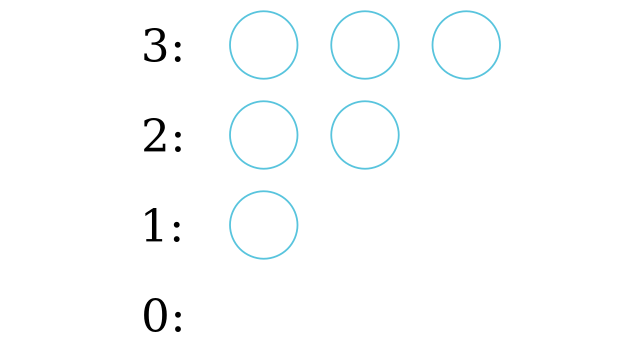

In [6]:
%%generate_image counting CountingDiagram

FONT_SIZE = 72

CIRCLE_WIDTH = 1.5
CIRCLE_COLOUR = BLUE

class CountingDiagram(Scene):
    def construct(self):
        # Three
        three_label = Text("3:", font_size=FONT_SIZE, color=BLACK)
        three_elements = VGroup(
            *[Circle(radius=CIRCLE_WIDTH/2, color=CIRCLE_COLOUR).shift(RIGHT*(i+1)*1.5*CIRCLE_WIDTH) for i in range(3)]
        )

        three_group = Group(three_label, three_elements)
        three_group.shift(3.5*LEFT)  # To align the label correctly
        three_group.shift(UP*3)
        self.add(three_group)

        # Two
        two_label = Text("2:", font_size=FONT_SIZE, color=BLACK)
        two_elements = VGroup(
            *[Circle(radius=CIRCLE_WIDTH/2, color=CIRCLE_COLOUR).shift(RIGHT*(i+1)*1.5*CIRCLE_WIDTH) for i in range(2)]
        )

        two_group = Group(two_label, two_elements)
        two_group.shift(3.5*LEFT)  # To align the label correctly
        two_group.shift(UP*1)
        self.add(two_group)

        # One
        one_label = Text("1:", font_size=FONT_SIZE, color=BLACK)
        one_elements = VGroup(
            Circle(radius=CIRCLE_WIDTH/2, color=CIRCLE_COLOUR).shift(RIGHT*1.5*CIRCLE_WIDTH)
        )

        one_group = Group(one_label, one_elements)
        one_group.shift(3.5*LEFT)  # To align the label correctly
        one_group.shift(DOWN*1)
        self.add(one_group)

        # Zero
        zero_label = Text("0:", font_size=FONT_SIZE, color=BLACK)
        zero_label.shift(3.5*LEFT)  # To align the label correctly
        zero_label.shift(DOWN*3)
        self.add(zero_label)

### The First 5 Counter Sets

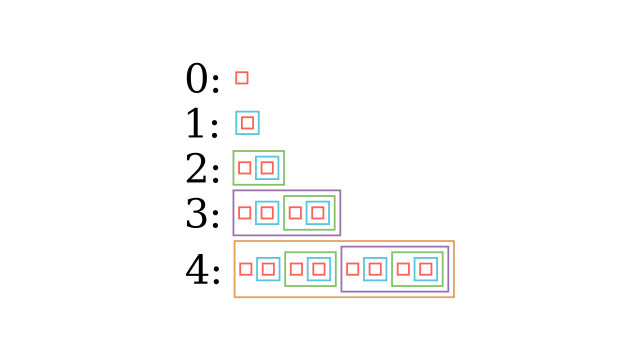

In [7]:
%%generate_image counter-sets CounterSetsDiagram

FONT_SIZE = 64

ZERO_BOX_WIDTH = 0.25

BUFF = 0.125
COLOURS = [RED, BLUE, GREEN, PURPLE, GOLD_D, TEAL_C]

def generate_set(scene: Scene, n: int, is_last: bool = True) -> Mobject:
    if n == 0:
        return Square(side_length=ZERO_BOX_WIDTH, color=COLOURS[0])
    
    sets = []
    for i in range(n):
        sets.append(generate_set(scene, i, is_last=False))
    
    sets_group = VGroup(*sets)
    current_shift = BUFF
    for s in sets:
        s.shift(current_shift * RIGHT)
        current_shift += s.width + BUFF

    surround = SurroundingRectangle(sets_group, buff=BUFF, color=COLOURS[n%len(COLOURS)])
    scene.add(sets_group)

    the_set = VGroup(sets_group, surround)

    if is_last:
        the_set = the_set.center()
    return the_set


class CounterSetsDiagram(Scene):
    def construct(self):
        # Zero
        zero_label = Text("0:", font_size=FONT_SIZE, color=BLACK)
        zero_set = generate_set(self, 0).shift(0.875*RIGHT)

        zero_group = Group(zero_label, zero_set)
        zero_group.shift(3.5*LEFT)  # To align the label correctly
        zero_group.shift(UP*2)

        # One
        one_label = Text("1:", font_size=FONT_SIZE, color=BLACK)
        one_set = generate_set(self, 1).shift(RIGHT)

        one_group = Group(one_label, one_set)
        one_group.shift(3.5*LEFT)  # To align the label correctly
        one_group.shift(UP*1)

        # Two
        two_label = Text("2:", font_size=FONT_SIZE, color=BLACK)
        two_set = generate_set(self, 2).shift(1.25*RIGHT)

        two_group = Group(two_label, two_set)
        two_group.shift(3.5*LEFT)  # To align the label correctly
        two_group

        # Three
        three_label = Text("3:", font_size=FONT_SIZE, color=BLACK)
        three_set = generate_set(self, 3).shift(1.875*RIGHT)

        three_group = Group(three_label, three_set)
        three_group.shift(3.5*LEFT)  # To align the label correctly
        three_group.shift(DOWN*1)

        # Four
        four_label = Text("4:", font_size=FONT_SIZE, color=BLACK)
        four_set = generate_set(self, 4).shift(3.15*RIGHT)

        four_group = Group(four_label, four_set)
        four_group.shift(3.5*LEFT)  # To align the label correctly
        four_group.shift(DOWN*2.25)

        # Add all
        all_groups = Group(
            zero_group, one_group, two_group, three_group, four_group
        )
        all_groups.center()
        self.add(all_groups)